# The Poisson illusion: internal traffic is not Poisson

Every decomposition of a network into independent nodes rests on a silent assumption: *the flow
between nodes is Poisson*. Burke's theorem says that's exactly true for M/M/c — and engineers
happily extrapolate. But the moment service times are variable (`C² > 1`), the departure process
of a queue is **burstier than Poisson**, the next node inherits that burstiness, and the
"independent nodes" estimate quietly loses 20%+ of the real latency.

The demo: a 3-node tandem, each node M/H₂/1 with service `C² = 4` at utilization 0.8. We compare
the plain decomposition (Poisson internal flows), **QNA** (Whitt 1983 — propagates the
two-moment variability through the network), and simulation as ground truth.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from most_queue.random.distributions import H2Distribution
from most_queue.sim.networks.network import NetworkSimulator
from most_queue.theory.networks.open_network import OpenNetworkCalc
from most_queue.theory.networks.qna import OpenNetworkCalcQNA

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3})

LAM, CV, RHO, M = 1.0, 2.0, 0.8, 3
# tandem routing: source -> 1 -> 2 -> 3 -> out
R = np.matrix([[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1]], dtype=float)

b, serv_params = [], []
for _ in range(M):
    h2 = H2Distribution.get_params_by_mean_and_cv(RHO / LAM, CV)
    serv_params.append({"type": "H", "params": h2})
    b.append(H2Distribution.calc_theory_moments(h2, 4))

plain = OpenNetworkCalc(); plain.set_sources(arrival_rate=LAM, R=R); plain.set_nodes(b=b, n=[1]*M)
v_plain = plain.run().v[0]

qna = OpenNetworkCalcQNA(); qna.set_sources(arrival_rate=LAM, R=R); qna.set_nodes(b=b, n=[1]*M)
v_qna = qna.run().v[0]
print("arrival cv2 seen by each node (QNA):", [round(c, 2) for c in qna.arrival_cv2_nodes])

arrival cv2 seen by each node (QNA):

[1.0, 2.92, 3.61]

In [2]:
%%capture
# ground truth: discrete-event simulation (tqdm progress captured)
np.random.seed(42)
sim = NetworkSimulator(); sim.set_sources(arrival_rate=LAM, R=R); sim.set_nodes(serv_params=serv_params, n=[1]*M)
v_sim = sim.run(200_000).v[0]

The first node sees the true Poisson input (`c² = 1`), but its **departures** leave with
`c² ≈ 1 + ρ²(C²−1) ≈ 3` — and nodes 2 and 3 queue against that burstier flow. The Poisson
assumption misses exactly this.

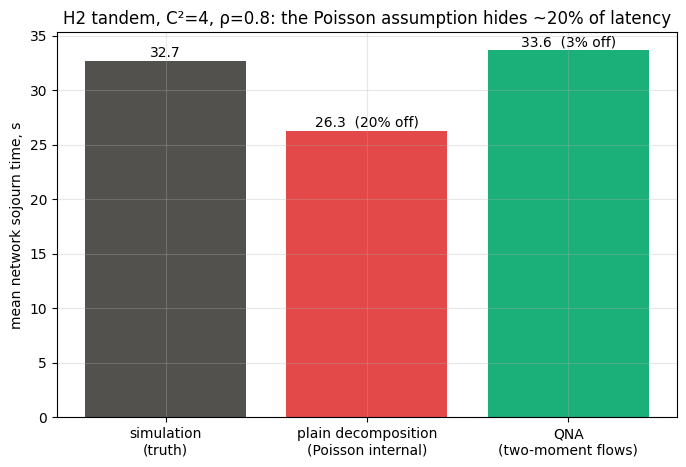

In [3]:
vals = {"simulation\n(truth)": v_sim, "plain decomposition\n(Poisson internal)": v_plain, "QNA\n(two-moment flows)": v_qna}
fig, ax = plt.subplots()
bars = ax.bar(vals.keys(), vals.values(), color=["#52514e", "#e34948", "#1baf7a"])
for rect, v in zip(bars, vals.values()):
    err = "" if v == v_sim else f"  ({100*abs(v-v_sim)/v_sim:.0f}% off)"
    ax.text(rect.get_x() + rect.get_width()/2, v + 0.4, f"{v:.1f}{err}", ha="center")
ax.set_ylabel("mean network sojourn time, s")
ax.set_title("H2 tandem, C²=4, ρ=0.8: the Poisson assumption hides ~20% of latency")
plt.show()

## When the illusion is legal: Burke's theorem

With **exponential** service the illusion is a theorem: the departure process of M/M/c is again
Poisson, internal flows really are Poisson, and the plain decomposition is exact (that's the
Jackson product form). QNA knows this: feed it exponential service and it reports `c² = 1`
everywhere and reproduces Erlang C at every node.

In [4]:
mu = 1.25
b_exp = [[1/mu, 2/mu**2, 6/mu**3]] * 2
R2 = np.matrix([[1,0,0],[0,1,0],[0,0,1]], dtype=float)
qna2 = OpenNetworkCalcQNA(); qna2.set_sources(arrival_rate=1.0, R=R2); qna2.set_nodes(b=b_exp, n=[1,1])
res2 = qna2.run()
print("internal flow c2 with exponential service:", [round(c, 6) for c in qna2.arrival_cv2_nodes])
print(f"per-node sojourn {res2.v_node[0]:.4f} s == M/M/1 exact {1/(mu-1.0):.4f} s (Burke)")

internal flow c2 with exponential service:

[1.0, 1.0]

per-node sojourn 4.0000 s == M/M/1 exact 4.0000 s (Burke)

## Takeaway

- **Departures inherit variability**: after an M/G/1 node, `c²_d ≈ 1 + ρ²(C²−1)`. Chain a few
  high-variance services and the last node sees traffic far burstier than your load generator.
- Decomposition with Poisson internal flows (still the default in many capacity tools)
  **systematically underestimates** latency on variable traffic — here by 20% at three nodes;
  it gets worse with depth and load.
- QNA-style two-moment propagation (`OpenNetworkCalcQNA`) closes most of the gap for the price
  of a fixed-point iteration; it also accepts bursty *external* traffic (see `map_arrival_cv2`
  for MAP inputs) — though it still ignores autocorrelation, the next level of the illusion.
- Only exponential service earns the Poisson assumption — that's Burke's theorem, and it is the
  exception, not the rule.